In [1]:
# Importing libaries 
import numpy as np
import pandas as pd
import matplotlib.pylab as plt 
import seaborn as sns

In [2]:
#importing the dataset. 

df = pd.read_csv('../data/Sleep_health_and_lifestyle_dataset.csv')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
sleep_count = df["Sleep Disorder"].value_counts()
sleep_count

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [4]:
# Chekcing the people who have sleep discorder .... sleep apnea with occuption 
sleep_apnea_occp = df[df['Sleep Disorder'] == "Sleep Apnea"]
sleep_apnea_occp["Occupation"]

3      Sales Representative
4      Sales Representative
16                    Nurse
17                   Doctor
30                    Nurse
               ...         
369                   Nurse
370                   Nurse
371                   Nurse
372                   Nurse
373                   Nurse
Name: Occupation, Length: 78, dtype: object

In [5]:
df[df["Sleep Disorder"] == "Sleep Apnea"]["Occupation"].value_counts()

Occupation
Nurse                   61
Doctor                   4
Teacher                  4
Lawyer                   3
Scientist                2
Sales Representative     2
Engineer                 1
Salesperson              1
Name: count, dtype: int64

In [6]:
sleep_apnea = df[df["Sleep Disorder"] == "Sleep Apnea"]
occupation_counts = sleep_apnea["Occupation"].value_counts()
print(occupation_counts)

Occupation
Nurse                   61
Doctor                   4
Teacher                  4
Lawyer                   3
Scientist                2
Sales Representative     2
Engineer                 1
Salesperson              1
Name: count, dtype: int64


In [7]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

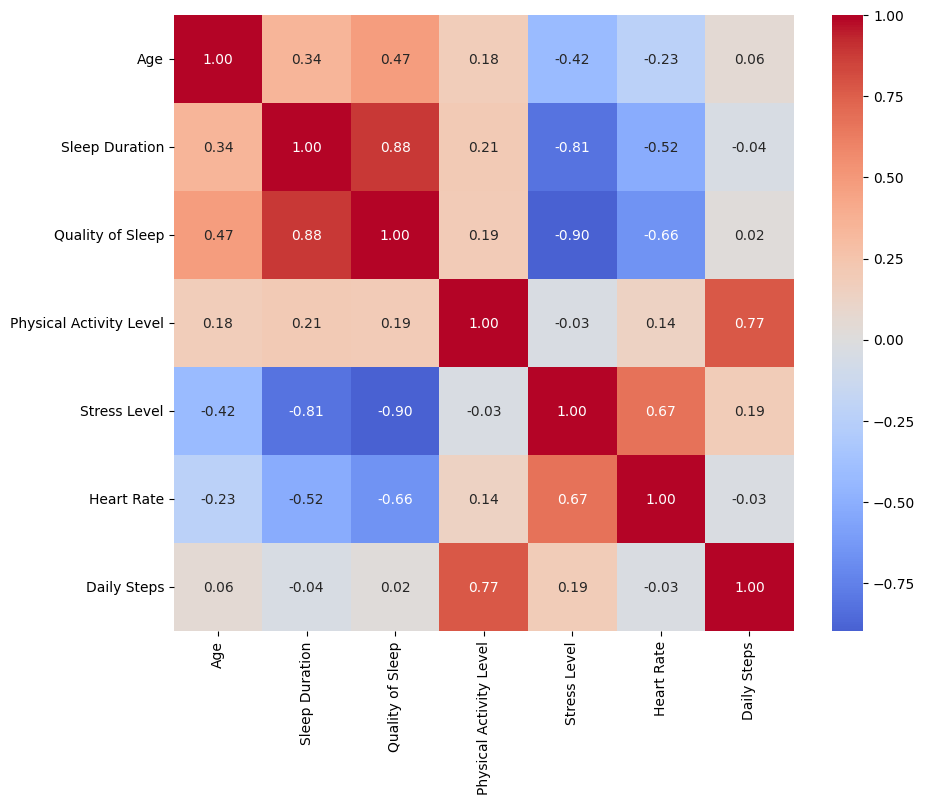

In [8]:
# Heatmap

numerical_col = ['Age','Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level','Heart Rate', 'Daily Steps']

corr = df[numerical_col].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
               annot=True,       # show numbers
               fmt='.2f',        # 2 decimal places
               cmap='coolwarm',  # red = positive, blue = negative
               center=0)
plt.show()

More sleep duration = Better sleep quality

Higher stress = Worse sleep quality

-0.90 is almost a perfect negative relationship!
Stress is the BIGGEST enemy of sleep quality
in this dataset ,stronger than any other factor.

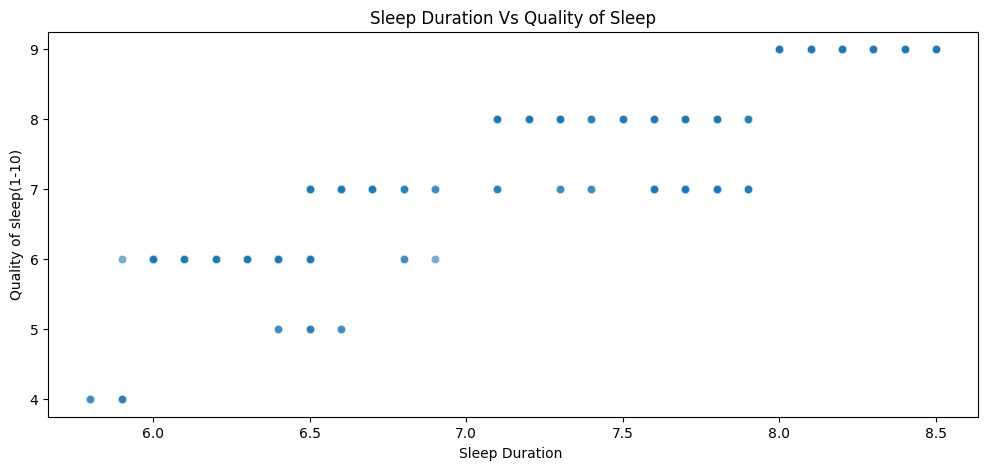

In [10]:
plt.figure(figsize=(12,5))
sns.scatterplot(data=df,
               x='Sleep Duration',
               y='Quality of Sleep',
               alpha=0.6)
plt.title("Sleep Duration Vs Quality of Sleep")
plt.xlabel("Sleep Duration ")
plt.ylabel("Quality of sleep(1-10)")
plt.show()

As Sleep Duration increases → Quality of Sleep increases

The relationship is clean, clear, and consistent

No outliers disturbing the pattern

# Stress Level vs Quality of Sleep to see the negative relationship:

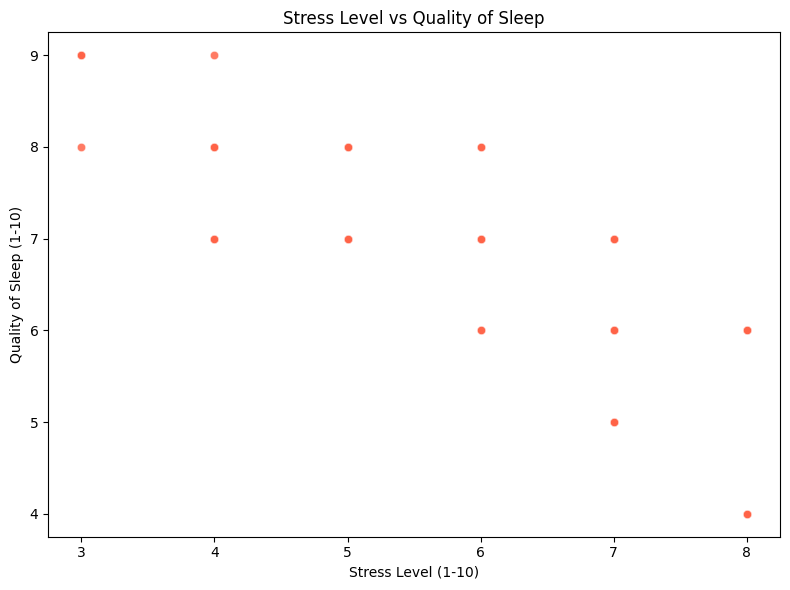

In [11]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df,
                    x='Stress Level',
                    y='Quality of Sleep',
                    color='tomato',
                    alpha=0.6)

plt.title('Stress Level vs Quality of Sleep')
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Quality of Sleep (1-10)')
plt.tight_layout()
plt.show()

As Stress Level increases → Quality of Sleep decreases

Again clean, clear and consistent

No outliers disturbing the pattern

# 
Sleep Duration  ↑  →  Quality of Sleep ↑  (positive)
Stress Level    ↑  →  Quality of Sleep ↓  (negative)

# Occupation vs Quality of Sleep — Categorical vs Numerical

C:\Users\mahar\AppData\Local\Temp\ipykernel_9948\3450668353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


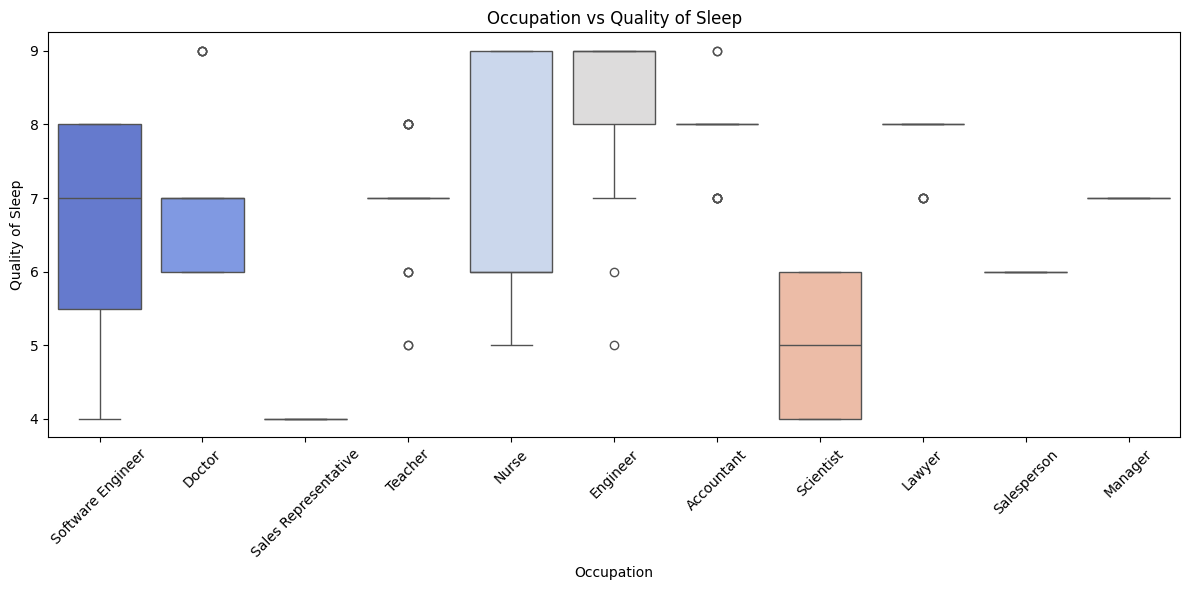

In [12]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df,
               x='Occupation',
               y='Quality of Sleep',
               palette='coolwarm')

plt.title('Occupation vs Quality of Sleep')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Engineer  → median ~8.5, very consistent

Nurse     → median ~7, but wide range (5-9)

- Worst Sleep Quality 
Scientist         → median ~5, lowest of all

Sales Representative → very low, no spread (flat line)

Software Engineer → wide range 4-8, very inconsistent

High stress jobs (Sales, Scientist) = poor sleep
Stable jobs (Engineer, Doctor)      = better sleep

In [15]:
df.groupby('Occupation')['Quality of Sleep'].mean().sort_values()

Occupation
Sales Representative    4.000000
Scientist               5.000000
Salesperson             6.000000
Software Engineer       6.500000
Doctor                  6.647887
Teacher                 6.975000
Manager                 7.000000
Nurse                   7.369863
Accountant              7.891892
Lawyer                  7.893617
Engineer                8.412698
Name: Quality of Sleep, dtype: float64